# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/1. IT study/Data Loves Academy/Data Analyst/11. Модуль 11/data/yulu_rental.csv')

# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

Mounted at /content/drive



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

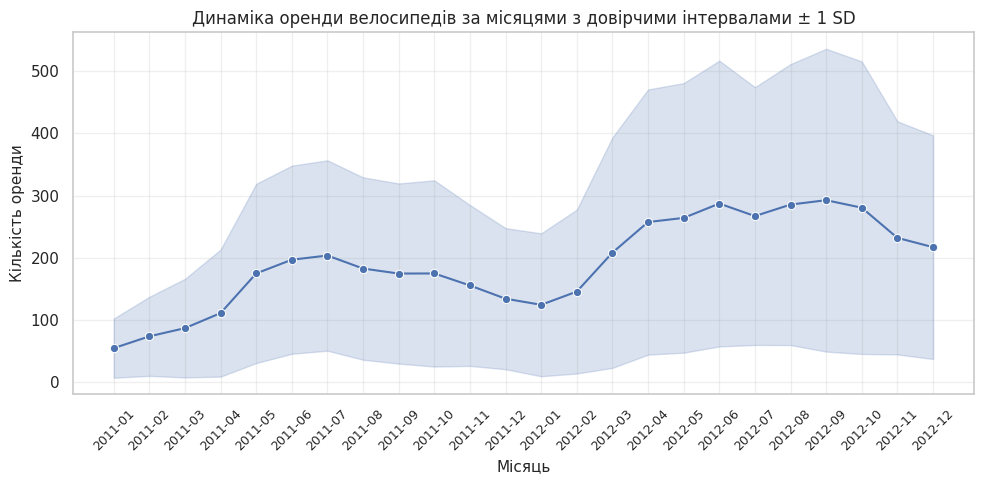

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year'] = df['month_year'].astype(str)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    errorbar='sd',      # confidence interval згідно умови: середнє значення ± 1 standard deviation
    marker='o'          # маркери-крапки на основній лінії
)

plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами ± 1 SD')
plt.xlabel('Місяць', fontsize=11)
plt.ylabel('Кількість оренди', fontsize=11)

plt.xticks(rotation=45, fontsize=9)   # трохи менші підписи X
plt.grid(alpha=0.3)                   # світліша сітка

plt.tight_layout()
plt.show();

**В які місяці найбільша невизначеність в даних**

Визначаємо найбільшу невизначеність в даних за шириною замальованої області. Чим ширша область - тим більше стандартне відхилення і, відповідно, більша варіативність даних.

Найбільша невизначеність у даних спостерігається в **серпні–жовтні 2012 року**, оскільки саме в ці місяці довірчий інтервал має найбільшу ширину.

Також досить велика невизначеність у квітні–липні 2012.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

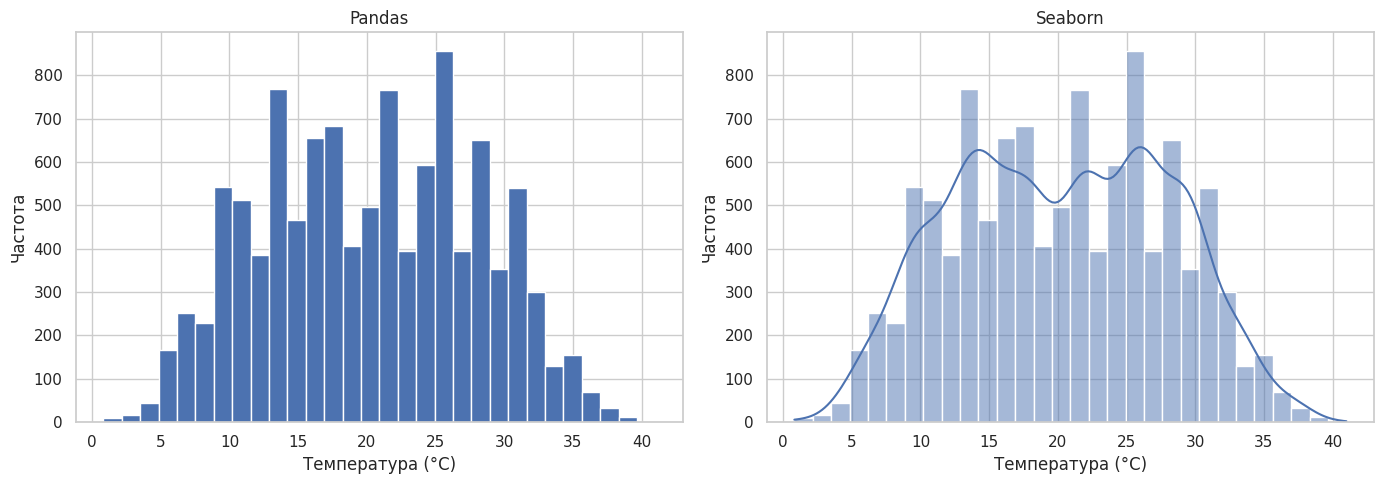

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pandas
df['temp'].plot.hist(
    bins=30,
    ax=axes[0]
)

axes[0].set_title('Pandas')
axes[0].set_xlabel('Температура (°C)')
axes[0].set_ylabel('Частота')


# Seaborn
sns.histplot(
    data=df,
    x='temp',
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Seaborn')
axes[1].set_xlabel('Температура (°C)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Візуально гістограми дуже схожі, тому що вони показують той самий розподіл температури `temp` і ми задали для обох способів по 30 бінів.

Водночас в Seaborn додатково з'явилася плавна лінія щільності розподілу KDE (Kernel Density Estimation), яка показує загальну форму розподілу температури і дозволяє краще оцінити загальну форму даних.



## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

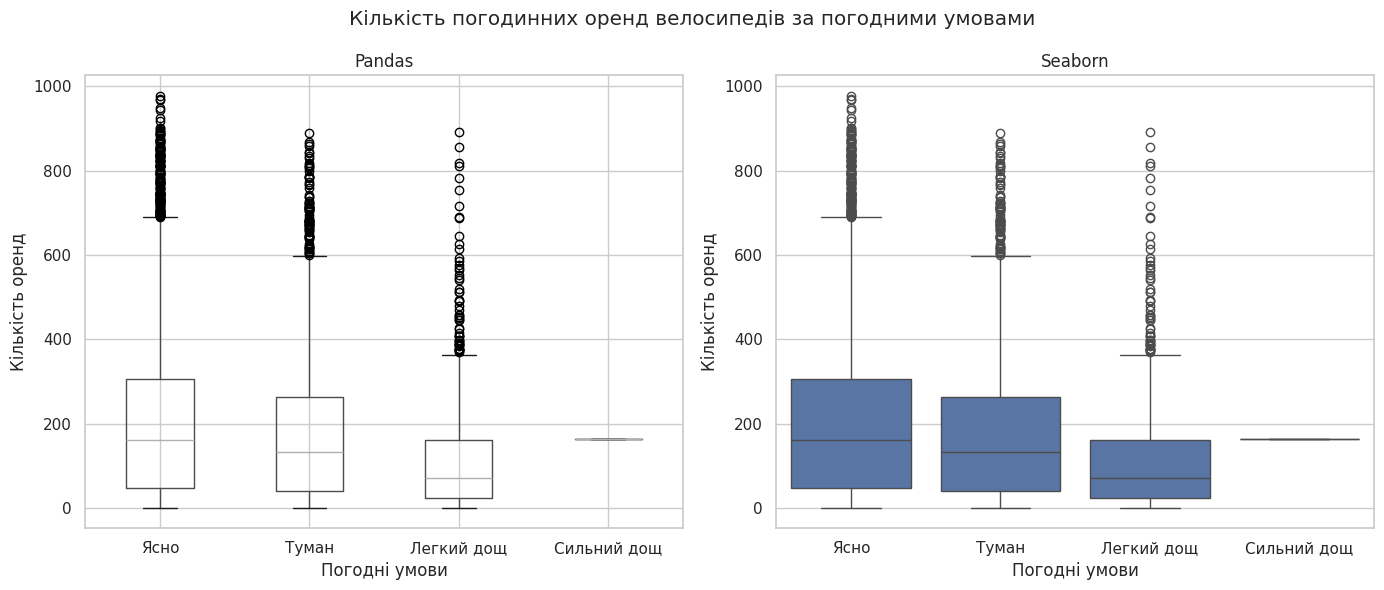

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Назви погодних умов українською
weather_names = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_name'] = df['weather'].map(weather_names)

# Задаємо однаковий порядок погодних умов
weather_order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

df['weather_name'] = pd.Categorical(
    df['weather_name'],
    categories=weather_order,
    ordered=True
)

# Створюємо одну фігуру з двома графіками
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot за допомогою Pandas
df.boxplot(
    column='count',
    by='weather_name',
    ax=axes[0]
)

axes[0].set_title('Pandas')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренд')

# Box plot за допомогою Seaborn
sns.boxplot(
    data=df,
    x='weather_name',
    y='count',
    ax=axes[1]
)

axes[1].set_title('Seaborn')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренд')

# Заголовок всієї фігури
plt.suptitle('Кількість погодинних оренд велосипедів за погодними умовами')

plt.tight_layout()
plt.show()

**Seaborn boxplot** за замовчуванням без додаткових налаштувань заливки бокса виглядає **більш презентабельно**, у Seaborn більша ширина боксів, а викиди за замовчуванням позначились сірим кольором. В той час Pandas бокс-плоти без заливки, викиди позначені чорним кольором.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


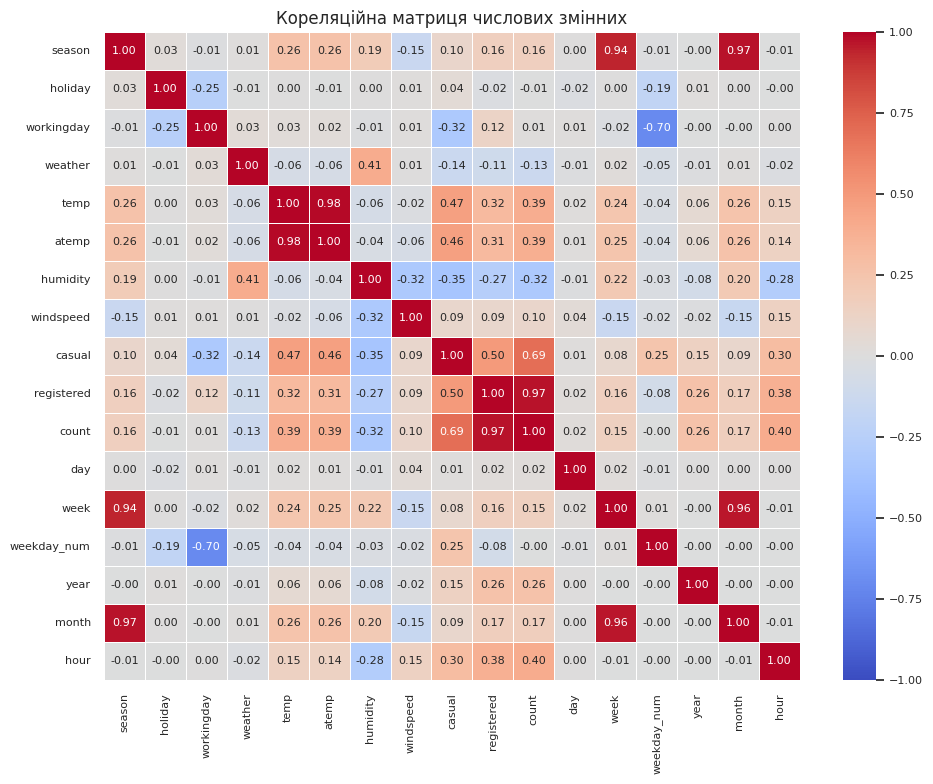

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Кореляційна матриця числових змінних
corr = df.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
     corr,
     annot=True,      # показати значення кореляції в клітинках
     fmt='.2f',       # 2 знаки після коми
     cmap='coolwarm', # колір відповідає величині та напрямку кореляції
     linewidths=0.5,
     annot_kws={'size': 8},
     vmin=-1, vmax=1,   # щоб колір завжди відповідав шкалі від -1 до 1
     center=0
)

# Зменшуємо шрифт цифр на шкалі кольорів (colorbar)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

plt.title('Кореляційна матриця числових змінних')
plt.xticks(fontsize=8)  # підписи знизу
plt.yticks(fontsize=8)  # підписи зліва
plt.tight_layout()
plt.show()

1. Які змінні найсильніше корелюють з count?

Найсильніші зв'язки (за модулем):

- `registered`: 0.97 (дуже сильна)
- `casual`: 0.69 (сильна)
- `month`: 0.39
- `temp`: 0.39
- `atemp`: 0.39
- `hour`: 0.40
- `humidity`: -0.32 (від'ємна)

`registered` і `casual` мають найвищу кореляцію не випадково: `count = casual + registered`, вони не є незалежними змінними, а складові однієї змінної `count`. Використовувати їх для побудови моделі, яка передбачає `count`, - не дуже коректно (data leakage / витік даних).

Якщо виключити ці дві колонки, то найсильніші реальні («корисні») - це `hour` (0.40), `temp`/`atemp` (0.39) та `humidity` (-0.32). І це логічно: попит на оренду залежить від пори доби, температури, вологості.

2. Кореляція між `temp` та `atemp` - чому вона така?

Кореляція = 0.98 - майже ідеальна.

Причина: `atemp` - це "відчувана температура" (apparent temperature), яка розраховується на основі `temp` із врахуванням вологості та вітру. Оскільки вона по суті є похідною/модифікованою версією `temp`, а не незалежним вимірюванням, - тому обидві змінні рухаються практично синхронно.

3. Які змінні мають негативну кореляцію?

- `workingday` ↔ `weekday_num`	(-0.70)	залежить від того, як закодовано дні тижня (вихідні мають більші номери)
- `workingday` ↔ `holiday`	(-0.25)	святкові дні зазвичай не робочі
- `humidity` ↔ `windspeed`	(-0.32)	типова метеорологічна закономірність
- `humidity` ↔ `casual`/`registered`/`count`	(-0.27...-0.35)	у вологу погоду менше орендують велосипеди
- `season`/`week`/`month` ↔ `windspeed`	(-0.15)	слабкий зв'язок сезону з вітряністю
- `weekday_num` ↔ `holiday`	(-0.19)

Більшість цих від'ємних зв'язків пояснюються або способом кодування категоріальних змінних (`workingday`, `weekday_num`, `holiday`), або природними погодними закономірностями (`humidity`, `windspeed`) та їхнім впливом на попит.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


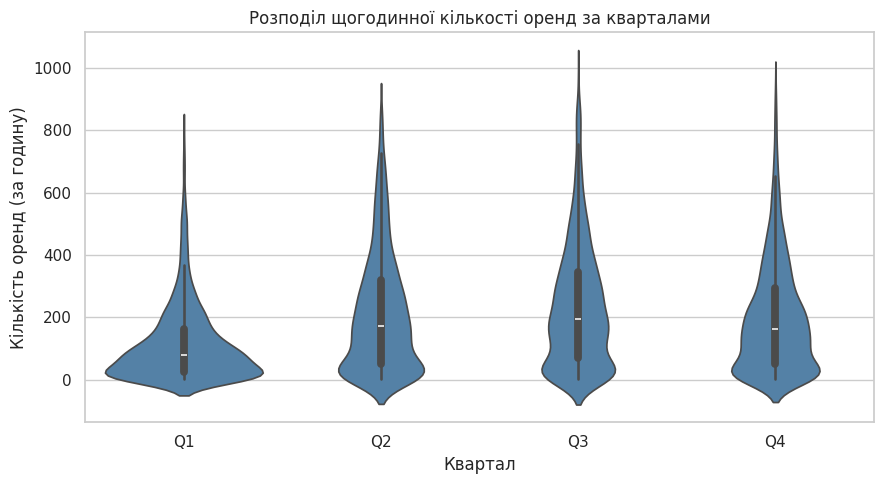

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Violin plot: розподіл count за кварталами (season)
plt.figure(figsize=(9, 5))

sns.violinplot(
    data=df,
    x='season',
    y='count',
    color='steelblue'
)

plt.title('Розподіл щогодинної кількості оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд (за годину)')
plt.xticks([0, 1, 2, 3], ['Q1', 'Q2', 'Q3', 'Q4'])  # підписи замість 1,2,3,4
plt.tight_layout()
plt.show()

Порівняємо явно візуально Violin Plot із Box Plot. Для зручності порівняння для кожного кварталу візьмемо окремий колір:

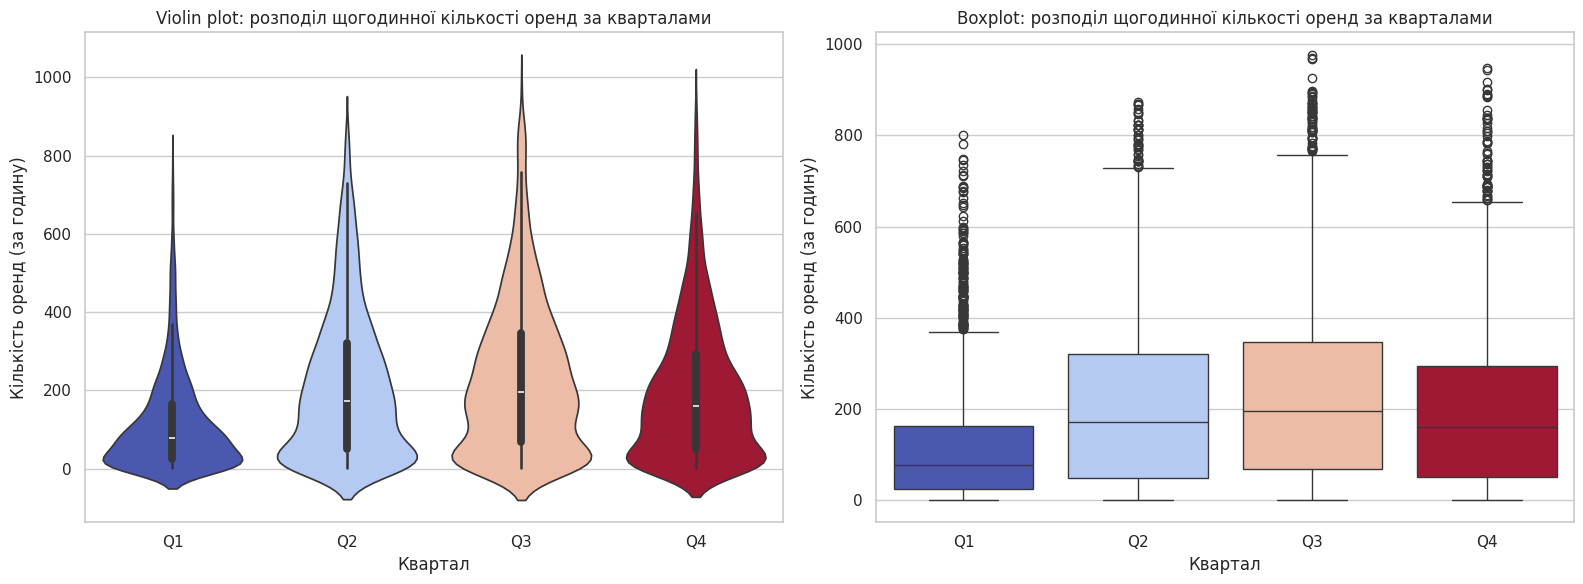

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Зліва - violin plot
sns.violinplot(
    data=df,
    x='season',
    y='count',
    hue='season',
    palette='coolwarm',
    legend=False,
    ax=ax1
)
ax1.set_title('Violin plot: розподіл щогодинної кількості оренд за кварталами')
ax1.set_xlabel('Квартал')
ax1.set_ylabel('Кількість оренд (за годину)')
ax1.set_xticks([0, 1, 2, 3])
ax1.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

# Справа - класичний boxplot
sns.boxplot(
    data=df,
    x='season',
    y='count',
    hue='season',
    palette='coolwarm',
    legend=False,
    ax=ax2
)
ax2.set_title('Boxplot: розподіл щогодинної кількості оренд за кварталами')
ax2.set_xlabel('Квартал')
ax2.set_ylabel('Кількість оренд (за годину)')
ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

plt.tight_layout()
plt.show()

1. **Що показує "товщина" Violin Plot?**

Товщина в кожній точці по вертикалі показує щільність (density) розподілу - тобто наскільки часто зустрічаються значення `count` на цьому рівні. Чим ширша "скрипка" в певній точці, тим більше спостережень (в нашому випадку - годин) мають приблизно таке значення кількості оренд.

На нашій візуалізації усі квартали мають найбільшу товщину внизу (біля 0-100) - це означає, що найчастіше трапляються години з низьким попитом, а вгору "скрипка" звужується, бо годин з дуже високим попитом (400-1000) значно менше.



2. **В якому кварталі найбільша варіабельність оренди?**

Q3 (і трохи менше Q4 та Q2) - там найбільший розкид даних:

У Q3 найвищі "вуса" на boxplot приблизно на рівні 750 оренд, а максимальні викиди сягають ~950-1000.
Найширше "тіло" violin plot у середній частині (100-600) - тобто в Q3 значення розкидані по ширшому діапазону, а не сконцентровані біля низьких показників, як у Q1.
Міжквартильний розмах (висота violin plot) у Q3 теж найбільший.

Для порівняння, Q1 має найменшу варіабельність - вузька "скрипка" сильно звужена вгорі, box компактний, максимальні викиди найнижчі (~800).

3. **Яка перевага Violin Plot над звичайним boxplot?**

Boxplot показує основні опорні статистики: медіану, квартилі, вуса та викиди - тобто "скелет" розподілу. Він не показує, чи дані всередині кожного квартиля розподілені рівномірно, чи концентруються в певних точках.

Violin Plot додає до цього форму розподілу (density), тому дозволяє побачити те, що boxplot приховує:

- **Унімодальний чи мультимодальний** розподіл - наприклад, чи є два піки попиту, які злилися в один boxplot з широким діапазоном.
- **Асиметрію** (skewness) - на наших графіках чітко видно, що розподіл сильно скошений праворуч (довгий "хвіст" вгору при основній масі даних внизу) - на boxplot це видно гірше, лише за розташуванням медіани всередині box.
- **Концентрацію даних** - наприклад, у Q1 видно, що переважна більшість значень тісно скупчена біля 0-100 (дуже вузька і товста нижня частина скрипки), тоді як boxplot просто покаже "медіана низька" без деталей про щільність.

Тобто Violin Plot дає ту саму інформацію, що і Boxplot (медіана, квартилі видно через вбудований міні-boxplot всередині), + повну картину форми розподілу - це особливо корисно, коли дані розподілені нерівномірно, як у нашому випадку з погодинною орендою велосипедів.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

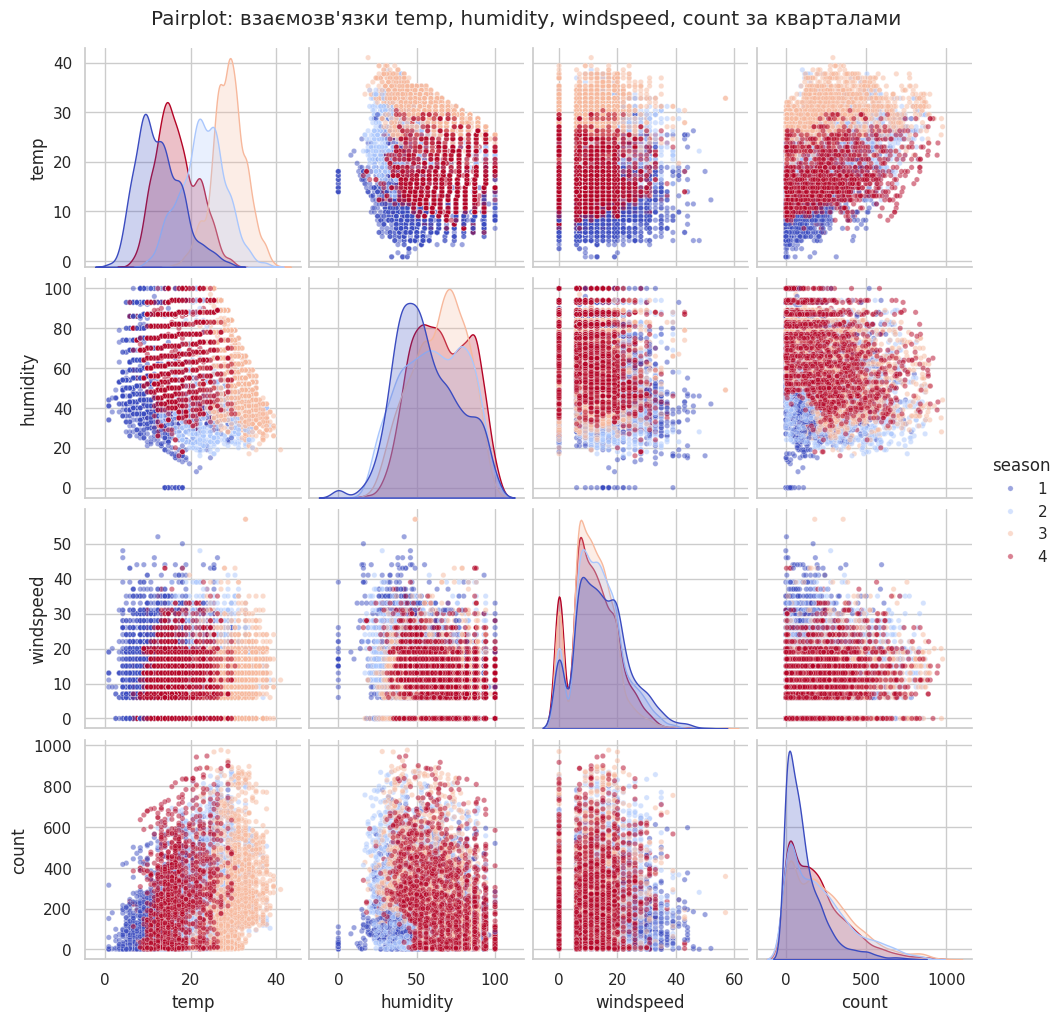

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Обираємо ключові змінні для аналізу
cols = ['temp', 'humidity', 'windspeed', 'count', 'season']

# Pairplot з розбивкою за кварталами (season)
g = sns.pairplot(
    data=df[cols],
    hue='season',
    palette='coolwarm',
    diag_kind='kde',      # на діагоналі - криві щільності замість гістограм
    plot_kws={'alpha': 0.5, 's': 15}  # прозорість і розмір точок для кращої читабельності
)

g.fig.suptitle('Pairplot: взаємозв\'язки temp, humidity, windspeed, count за кварталами', y=1.02)
plt.show()

1. **Найсильніший лінійний зв'язок**

З представлених на Pairplot змінних (`temp`, `humidity`, `windspeed`, `count`) явного сильного лінійного (прямолінійного) зв'язку не видно в жодній парі - всі scatter plots виглядають як "хмари" точок без чіткої лінійної форми.

Найбільш виражений (хоч і не строго лінійний, а швидше загальна тенденція) зв'язок - це `temp` ↔ `count`: на графіку видно, що при низьких `temp` (0-10) ‼️ по осі 0X ‼️  значення `count` рідко перевищують 400-500, а при вищих temp (20-35) з'являється набагато більше високих значень `count` (600-1000). Це узгоджується з кореляційною матрицею, де `temp` мав одну з найвищих кореляцій із `count` (0.39).

Для порівняння:

`humidity` ↔ `count` - слабший, зворотний зв'язок (при високій вологості високі значення `count` трапляються рідше), теж узгоджується з кореляцією -0.32.
`windspeed` ↔ `count`, `temp` ↔ `humidity`, `temp` ↔ `windspeed` - практично безформна хмара, зв'язку майже не видно.

Тобто серед цих чотирьох змінних `temp` ↔ `count` - найбільш чітко виражений (хоча й нелінійний, скоріше монотонний) зв'язок.

2. **Яка характеристика найбільше відрізняється між кварталами**

`temp` - найбільша різниця між кварталами, і це найкраще видно на діагональному графіку (KDE-криві температури):

Q1 (синій) і Q4 (червоний) - криві зміщені ліворуч, пік приблизно на 10-15°C (холодні квартали).
Q2 (світло-блакитний) і Q3 (персиковий) - криві зміщені праворуч, пік на 20-30°C (теплі квартали).

Криві розподілу `temp` для різних кварталів майже не перекриваються - це найчіткіше розділення серед усіх чотирьох змінних.

Для порівняння:

`humidity` - криві частково розділені (Q3 трохи зміщений праворуч, вища вологість), але перекриття значно більше, ніж у `temp`.
`windspeed` - криві майже ідентичні для всіх кварталів, різниця мінімальна.
`count` - розподіли теж досить схожі між кварталами, з невеликим зсувом (Q1 має трохи більше низьких значень).

Висновок: `temp` - це змінна, яка найкраще "розділяє" квартали візуально і це робить її найінформативнішою ознакою сезонності серед розглянутих чотирьох.

Нижче - допоміжні візуалізації.

In [ ]:
df.groupby('season')['temp'].median().sort_values()

,temp
season,
1,12.30
4,16.40
2,22.96
3,28.70


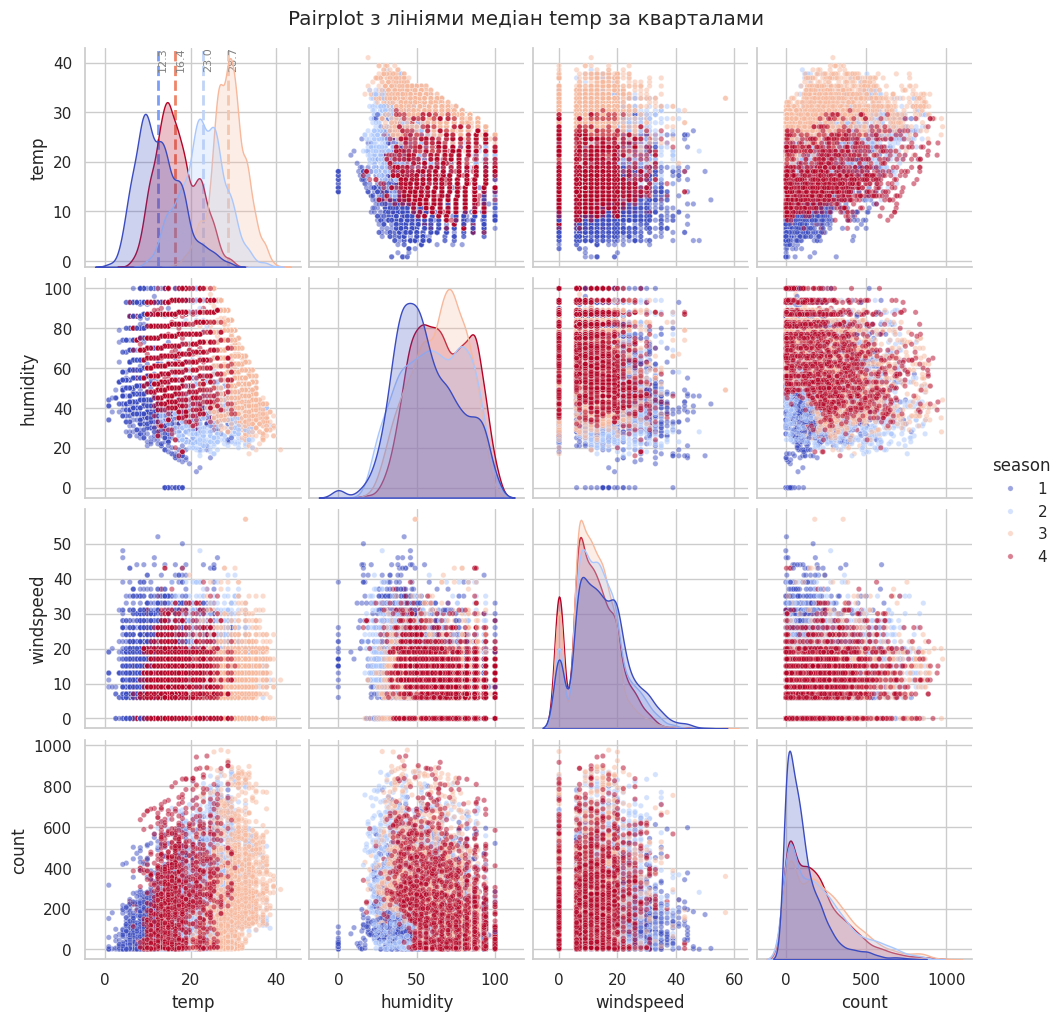

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['temp', 'humidity', 'windspeed', 'count', 'season']

g = sns.pairplot(
    data=df[cols],
    hue='season',
    palette='coolwarm',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15}
)

# Дістаємо кольори, які seaborn використав для кожного season
seasons_sorted = sorted(df['season'].unique())
palette_colors = sns.color_palette('coolwarm', n_colors=len(seasons_sorted))
season_color_map = dict(zip(seasons_sorted, palette_colors))

# Рахуємо медіану temp для кожного кварталу
medians = df.groupby('season')['temp'].median()

# Додаємо вертикальну лінію медіани на діагональну клітинку temp-temp
ax_temp = g.axes[0, 0]
for season, median_val in medians.items():
    ax_temp.axvline(
        median_val,
        color=season_color_map[season],
        linestyle='--',
        linewidth=2
    )
    # підписуємо значення прямо на графіку
    ax_temp.text(median_val, ax_temp.get_ylim()[1]*0.9, f'{median_val:.1f}',
                 rotation=90, color='gray', fontsize=8)

g.fig.suptitle('Pairplot з лініями медіан temp за кварталами', y=1.02)
plt.show()

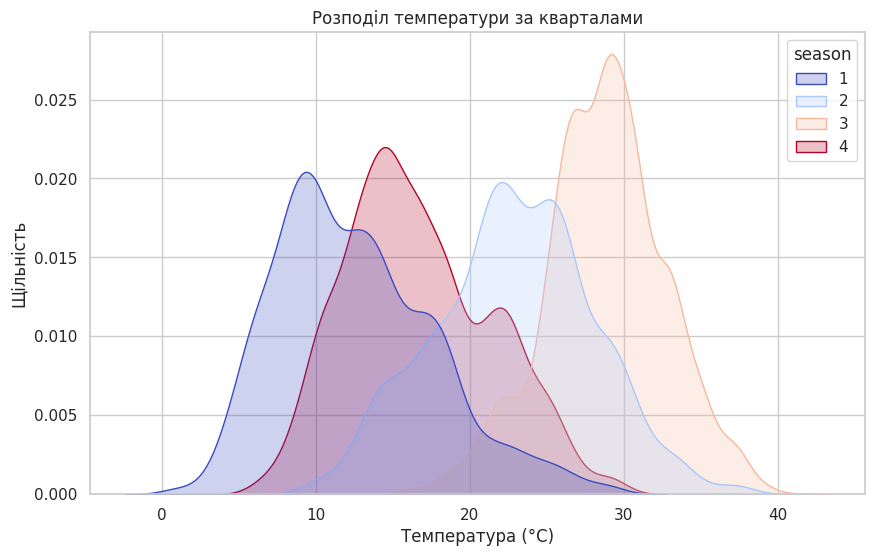

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='temp', hue='season', palette='coolwarm', fill=True)
plt.title('Розподіл температури за кварталами')
plt.xlabel('Температура (°C)')
plt.ylabel('Щільність')
plt.show()

**Чому щільність - це дрібні числа, а не count**

`sns.kdeplot` будує не гістограму (де вісь Y = кількість спостережень), а оцінку функції густини ймовірності. Ключова математична властивість такої кривої - площа під кривою дорівнює 1 (тобто 100% усіх спостережень).

Оскільки дані розтягнуті на широкому діапазоні (від 0 до 40+ градусів), щоб площа під кривою залишалась рівно 1, висота кривої (вісь Y) має бути малою - приблизно 0.01-0.025, як на нашому графіку. Якби дані були стиснуті у вузькому діапазоні, висота була б набагато більшою, щоб компенсувати вузьку ширину і зберегти ту саму площу = 1.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

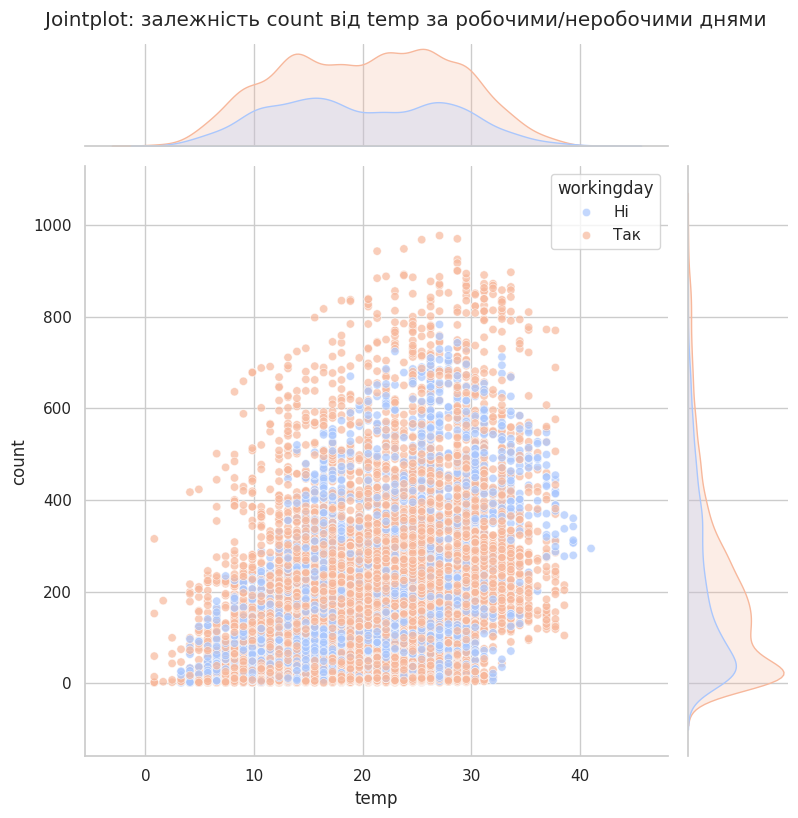

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Тимчасова копія лише з потрібними колонками, без зміни оригінального df
df_plot = df[['temp', 'count', 'workingday']].copy()
df_plot['workingday'] = df_plot['workingday'].map({0: 'Ні', 1: 'Так'})

g = sns.jointplot(
    data=df_plot,
    x='temp',
    y='count',
    hue='workingday',
    palette='coolwarm',
    alpha=0.7,
    height=8
)

g.fig.suptitle('Jointplot: залежність count від temp за робочими/неробочими днями', y=1.02)
plt.show()

1. **Що показують графіки по краях?**

Графіки по краях - це проекції центрального scatter plot окремо на кожну вісь, з розбивкою за кольором на `workingday`.

- Верхній графік - розподіл (густина) значень `temp` окремо, без урахування `count`. Видно, що обидва розподіли (робочий/неробочий день) мають схожу форму - плато приблизно між 15-30°C, з піком трохи вищим для робочих днів (помаранчевий) у діапазоні 20-30°C.

- Правий графік - розподіл (густина) значень `count` окремо, без урахування `temp`. Тут різниця помітніша: обидва розподіли сильно скошені вправо (більшість значень `count` низькі, ближче до 0), але у робочих днів (помаранчевий) пік густини вищий і різкіший саме біля низьких значень `count` (~0-100).



2. **Чи є різниця у поведінці користувачів у робочий і неробочий день?**

Так, помітна різниця:

За розподілом `count` (правий графік): у робочі дні (помаранчевий) розподіл сильніше сконцентрований біля дуже низьких значень `count`, ніж у неробочі (блакитний). Це означає, що типова година в робочий день частіше має малий попит (наприклад, глибока ніч чи середина робочого дня, коли люди на роботі й не орендують велосипед), а розподіл неробочих днів трохи більш "розмазаний" по середніх значеннях.

За центральним scatter plot: видно, що:

- Найвищі значення count (800-975) - це переважно помаранчеві точки (робочі дні), і вони зосереджені в діапазоні температур приблизно 20-30°C. Це узгоджується з логікою "піків годин пік" (ранок/вечір поїздок на роботу), коли за сприятливої погоди попит стрибає високо.
- Блакитні точки (неробочі дні) рідше досягають таких екстремальних значень `count` - їхній максимум приблизно 600-700, і вони більш рівномірно розкидані по всьому діапазону температур, з менш вираженим стрибком вгору.
При низьких температурах (0-10°C) обидва типи днів мають низький `count`, суттєвої різниці немає.

**Висновок**: робочі дні мають вищі пікові значення оренди (ймовірно, за рахунок постійного потоку registered-користувачів, що їдуть на роботу), тоді як неробочі дні мають більш рівномірний, "розмазаний" розподіл попиту без такого вираженого максимуму - це узгоджується з припущенням, що дозвіллєве катання менш прив'язане до конкретної години дня, а поїздки на роботу створюють різкі пікові навантаження в робочі дні.